
# Generative AI: From Autoencoders to Transformers

## A tutorial on **Autoencoders, VAEs, GANs, and the road to LLMs**

This notebook organized the as:

1. **Autoencoders** learn to compress and reconstruct data.
2. **Variational Autoencoders (VAEs)** make the latent space smooth enough for sampling.
3. **GANs** introduce an adversarial game between a generator and a discriminator.
4. **Transformers** shift the focus to **attention** and next-token prediction, which becomes the foundation for modern **LLMs**.

We will use a **small text corpus** to connect the ideas to language and to later understand how large language models work.

---

## Why this notebook is organized this way

A lot of students first meet LLMs as a black box.  
This notebook instead shows a progression:

- from **compressing text representations**,
- to **sampling from latent spaces**,
- to **generating realistic-looking outputs**,
- to **attention-based models** that predict text token by token.

By the end, you should be able to explain not only what these models do, but also **why the field gradually moved toward transformers for text generation**.



## 1. Big picture: discriminative vs. generative models

A **discriminative model** learns to answer questions like:

- "Is this review positive or negative?"
- "Is this email spam or not spam?"
- "Which class does this input belong to?"

A **generative model** learns something broader:

- "What does data from this world usually look like?"
- "Can I generate a new example that resembles the training data?"
- "Can I fill in missing pieces, reconstruct noisy inputs, or continue a text prompt?"

### Simple analogy

Imagine you are in a library.

- A **discriminative model** is like a librarian who quickly says  
  **"this book belongs in the history section."**
- A **generative model** is like a writer who has read thousands of books and can say  
  **"here is a new paragraph that sounds like it belongs in this library."**

That is why generative models feel creative: they do not just separate classes; they learn patterns that allow them to **reconstruct, sample, or continue** data.



## 2. A historical roadmap for this notebook

### Autoencoders
Learn a compressed representation that is good enough to reconstruct the input.

**Analogy:**  
You read a long paragraph, write down only the key points on a small card, then try to rewrite the paragraph from that card.

---

### Variational Autoencoders (VAEs)
Do not store each example as one exact point.  
Instead, learn a **distribution** in latent space so we can sample new points and decode them.

**Analogy:**  
Instead of storing one exact house address, you store a **neighborhood on a map**.  
Then you can pick a new location inside that neighborhood and still land in a place that “makes sense”.

---

### GANs
Use two models in competition:

- a **generator** that tries to produce convincing fake samples,
- a **discriminator** that tries to spot the fake ones.

**Analogy:**  
A forger tries to create realistic documents, while an inspector tries to detect fakes.  
As both improve, the forged documents become more convincing.

---

### Transformers
Instead of relying on a bottleneck or an adversarial game, transformers learn by **attention**:
each token can look at other tokens and decide which ones matter most.

**Analogy:**  
When reading a sentence, each word asks:  
**"Which other words should I pay attention to in order to understand my role here?"**

This attention-based idea becomes the core of modern **LLMs**.



## 3. Setup

This notebook is designed to stay lightweight and teach concepts clearly.

We will:

- build a **small synthetic text corpus**,
- convert text into numerical representations,
- train small demonstration models,
- and let you type your own text to inspect tokenization, latent vectors, attention, and generation.

> The models here are intentionally small and educational.  
> They are not meant to compete with production systems.


In [1]:

import os
import re
import math
import random
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)


I0000 00:00:1776466922.011582  225094 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776466922.014499  225094 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776466922.330199  225094 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776466924.046064  225094 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

TensorFlow version: 2.21.0



## 4. Build a tiny text world

To keep the notebook fast and interpretable, we will generate a synthetic corpus of short sentences from a few themes:

- study
- weather
- travel
- food
- sports
- technology

This gives us text with repeated structure, which is perfect for learning how models compress, reconstruct, sample, and generate.


In [2]:

def normalize_text(s):
    s = s.lower()
    s = re.sub(r"[^a-z0-9\s]", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

theme_parts = {
    "study": {
        "subjects": ["student", "teacher", "researcher", "group", "writer"],
        "verbs": ["reads", "reviews", "summarizes", "discusses", "writes"],
        "objects": ["report", "lesson", "article", "notebook", "project"],
        "mods": ["carefully", "quietly", "together", "before class", "after lunch"],
    },
    "weather": {
        "subjects": ["wind", "rain", "cloud", "sun", "storm"],
        "verbs": ["moves", "covers", "warms", "crosses", "changes"],
        "objects": ["city", "valley", "road", "coast", "morning sky"],
        "mods": ["slowly", "suddenly", "at sunrise", "during winter", "this evening"],
    },
    "travel": {
        "subjects": ["traveler", "tourist", "family", "pilot", "guide"],
        "verbs": ["boards", "visits", "explores", "maps", "leaves"],
        "objects": ["station", "museum", "harbor", "village", "mountain trail"],
        "mods": ["early", "by train", "with friends", "during summer", "before sunset"],
    },
    "food": {
        "subjects": ["chef", "cook", "baker", "family", "friend"],
        "verbs": ["prepares", "serves", "shares", "tastes", "packs"],
        "objects": ["soup", "bread", "dinner", "salad", "dessert"],
        "mods": ["warm", "fresh", "for guests", "after work", "in the kitchen"],
    },
    "sports": {
        "subjects": ["team", "player", "captain", "runner", "coach"],
        "verbs": ["wins", "practices", "improves", "finishes", "starts"],
        "objects": ["match", "session", "race", "drill", "season"],
        "mods": ["quickly", "with focus", "under pressure", "before rain", "every weekend"],
    },
    "technology": {
        "subjects": ["robot", "device", "system", "model", "sensor"],
        "verbs": ["detects", "sends", "stores", "predicts", "updates"],
        "objects": ["signal", "message", "pattern", "report", "network state"],
        "mods": ["in real time", "securely", "with low latency", "during testing", "after training"],
    },
}

templates = [
    "the {subject} {verb} the {object} {mod}",
    "a {subject} {verb} a {object} {mod}",
    "our {subject} {verb} the {object} {mod}",
    "the {subject} {verb} this {object} {mod}",
]

sentences = []
topics = []

for topic, parts in theme_parts.items():
    for _ in range(90):
        template = random.choice(templates)
        sentence = template.format(
            subject=random.choice(parts["subjects"]),
            verb=random.choice(parts["verbs"]),
            object=random.choice(parts["objects"]),
            mod=random.choice(parts["mods"]),
        )
        sentence = normalize_text(sentence)
        sentences.append(sentence)
        topics.append(topic)

df = pd.DataFrame({"text": sentences, "topic": topics}).drop_duplicates().reset_index(drop=True)
sentences = df["text"].tolist()
topics = df["topic"].tolist()

print("Number of sentences:", len(sentences))
df.sample(10, random_state=42)


Number of sentences: 531


,text,topic
517,the sensor updates the pattern during testing,technology
6,our teacher reviews the article carefully,study
322,our chef shares the bread fresh,food
416,the captain finishes the race before rain,sports
497,the robot detects the report during testing,technology
185,a traveler explores a village with friends,travel
75,the researcher reviews the lesson carefully,study
104,the rain crosses this coast at sunrise,weather
180,a tourist explores a mountain trail early,travel
403,the captain starts this season with focus,sports


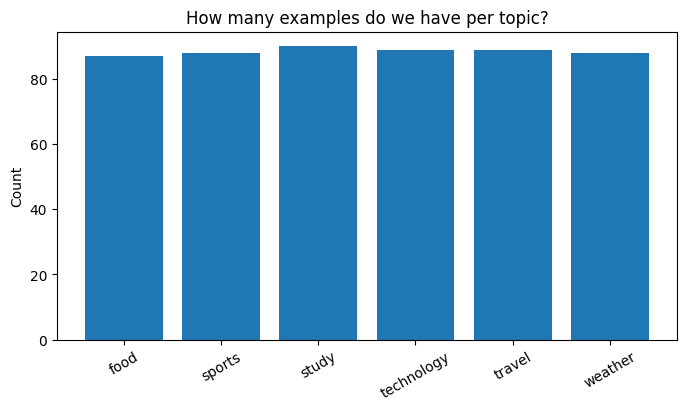

First five sentences:
- the student summarizes the lesson quietly
- a student writes a report after lunch
- the student reads this report quietly
- a writer writes a report after lunch
- a writer discusses a lesson before class


In [3]:

topic_counts = pd.Series(topics).value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(topic_counts.index, topic_counts.values)
plt.title("How many examples do we have per topic?")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

print("First five sentences:")
for s in sentences[:5]:
    print("-", s)



## 5. How text becomes numbers

Neural networks cannot directly process raw strings like:

> `"the student writes the report carefully"`

They need **numeric representations**.

We will use two useful views of the same text:

### A. Token IDs
Each word is mapped to an integer ID.

Example:

- `"the"` → 2
- `"student"` → 41
- `"writes"` → 88

This preserves **word order**.

### B. Multi-hot / bag-of-words vectors
Each dimension says whether a word appears in the sentence.

This loses **word order**, but it is very useful for learning autoencoders and VAEs because the vectors are simple and fast.

### Analogy

Think of two ways to store a grocery list:

- **Token IDs** = the exact ordered list you wrote.
- **Bag-of-words** = just a checklist of which items appear somewhere on the list.

Both are useful, but they answer different questions.


In [4]:

max_tokens = 500
sequence_length = 12

text_ds = tf.data.Dataset.from_tensor_slices(sentences).batch(32)

int_vectorizer = layers.TextVectorization(
    standardize="lower_and_strip_punctuation",
    split="whitespace",
    output_mode="int",
    output_sequence_length=sequence_length,
    max_tokens=max_tokens,
)

bow_vectorizer = layers.TextVectorization(
    standardize="lower_and_strip_punctuation",
    split="whitespace",
    output_mode="multi_hot",
    max_tokens=max_tokens,
)

int_vectorizer.adapt(text_ds)
bow_vectorizer.adapt(text_ds)

vocab = int_vectorizer.get_vocabulary()
vocab_size = len(vocab)

print("Vocabulary size:", vocab_size)
print("First 25 vocabulary items:")
print(vocab[:25])


E0000 00:00:1776466924.668531  225094 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error
I0000 00:00:1776466924.668595  225094 cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
I0000 00:00:1776466924.668599  225094 cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: lap
I0000 00:00:1776466924.668612  225094 cuda_diagnostics.cc:183] hostname: lap
I0000 00:00:1776466924.668909  225094 cuda_diagnostics.cc:190] libcuda reported version is: 580.126.9
I0000 00:00:1776466924.668941  225094 cuda_diagnostics.cc:194] kernel reported version is: 580.126.9
I0000 00:00:1776466924.668943  225094 cuda_diagnostics.cc:284] kernel version seems to match DSO: 580.126.9


Vocabulary size: 138
First 25 vocabulary items:
['', '[UNK]', np.str_('the'), np.str_('a'), np.str_('our'), np.str_('this'), np.str_('during'), np.str_('with'), np.str_('after'), np.str_('before'), np.str_('report'), np.str_('family'), np.str_('rain'), np.str_('in'), np.str_('crosses'), np.str_('coast'), np.str_('reads'), np.str_('starts'), np.str_('baker'), np.str_('weekend'), np.str_('trail'), np.str_('student'), np.str_('mountain'), np.str_('explores'), np.str_('every')]


In [5]:

def active_words_from_multihot(vec, vocabulary, threshold=0.5):
    words = []
    for i, value in enumerate(vec):
        if value >= threshold and i < len(vocabulary):
            token = vocabulary[i]
            if token not in ("", "[UNK]"):
                words.append(token)
    return words

def top_words_from_probs(vec, vocabulary, top_k=8):
    idx = np.argsort(vec)[::-1]
    words = []
    for i in idx:
        token = vocabulary[i]
        if token not in ("", "[UNK]"):
            words.append((token, float(vec[i])))
        if len(words) == top_k:
            break
    return words

def inspect_text_representation(text):
    text = normalize_text(text)
    token_ids = int_vectorizer(tf.constant([text])).numpy()[0]
    bow = bow_vectorizer(tf.constant([text])).numpy()[0]

    nonzero_ids = [int(i) for i in token_ids if i != 0]
    ordered_tokens = [vocab[i] for i in nonzero_ids]
    active_words = active_words_from_multihot(bow, vocab)

    print("Normalized text:", text)
    print("Token IDs:", nonzero_ids)
    print("Ordered tokens:", ordered_tokens)
    print("Bag-of-words active words:", active_words)

    return token_ids, bow

user_text = "the student writes the report carefully"
_ = inspect_text_representation(user_text)


Normalized text: the student writes the report carefully
Token IDs: [2, 21, 94, 2, 10, 37]
Ordered tokens: [np.str_('the'), np.str_('student'), np.str_('writes'), np.str_('the'), np.str_('report'), np.str_('carefully')]
Bag-of-words active words: [np.str_('before'), np.str_('trail'), np.str_('drill'), np.str_('dessert')]



## 6. The first key idea: autoencoders

An **autoencoder** has two parts:

- an **encoder** that compresses the input,
- a **decoder** that tries to reconstruct the original input from the compressed code.

### Better analogy: the travel summary card

Imagine you visited a city and only had room on a small card to write:

- 3 places you visited,
- 2 activities,
- 1 overall mood.

Later, another person tries to reconstruct your full trip story from that small card.

That card is the **latent representation** or **bottleneck**.

If the card is too small, important details are lost.  
If it is large enough, it can store the most important information in a compact way.

### In this notebook

We will start with a **bag-of-words autoencoder** for text.  
That means the model learns to reconstruct **which words appeared**, not their exact order.

This is not how modern text generation works, but it is a very clear way to understand:

- encoding,
- bottlenecks,
- reconstruction loss,
- and latent representations.


In [6]:

X_bow = bow_vectorizer(tf.constant(sentences)).numpy().astype("float32")
X_train, X_val, topic_train, topic_val, text_train, text_val = train_test_split(
    X_bow, topics, sentences, test_size=0.2, random_state=42, stratify=topics
)

input_dim = X_train.shape[1]
ae_latent_dim = 8

ae_encoder = keras.Sequential(
    [
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(ae_latent_dim, name="latent_code"),
    ],
    name="ae_encoder",
)

ae_decoder = keras.Sequential(
    [
        layers.Input(shape=(ae_latent_dim,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(input_dim, activation="sigmoid"),
    ],
    name="ae_decoder",
)

ae_inputs = keras.Input(shape=(input_dim,))
ae_latent = ae_encoder(ae_inputs)
ae_outputs = ae_decoder(ae_latent)
autoencoder = keras.Model(ae_inputs, ae_outputs, name="text_autoencoder")

autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
)

autoencoder.summary()


Model: "text_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 137)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ae_encoder (Sequential)         │ (None, 8)              │        11,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ae_decoder (Sequential)         │ (None, 137)            │        11,305 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,481 (87.82 KB)

 Trainable params: 22,481 (87.82 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:

ae_history = autoencoder.fit(
    X_train,
    X_train,
    validation_data=(X_val, X_val),
    epochs=25,
    batch_size=32,
    verbose=0,
)


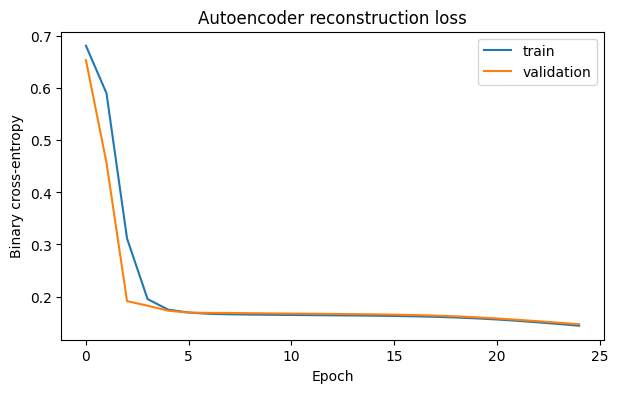

In [8]:

plt.figure(figsize=(7, 4))
plt.plot(ae_history.history["loss"], label="train")
plt.plot(ae_history.history["val_loss"], label="validation")
plt.title("Autoencoder reconstruction loss")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.legend()
plt.show()


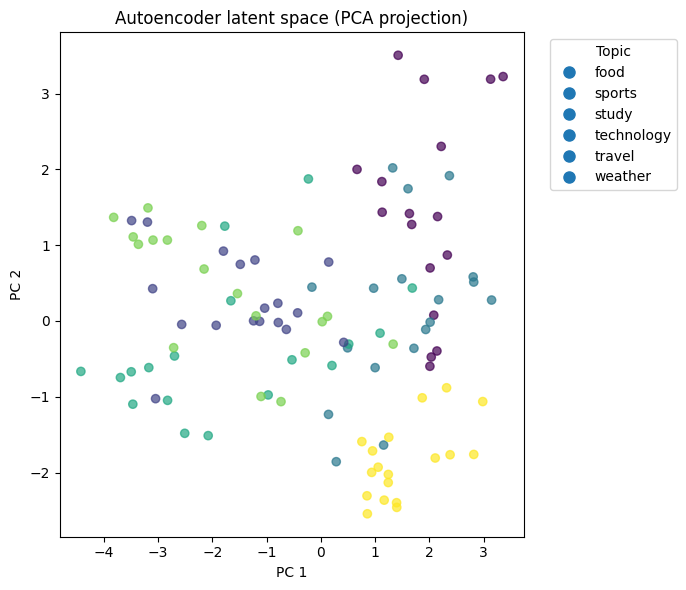

In [9]:

latent_codes = ae_encoder.predict(X_val, verbose=0)
pca = PCA(n_components=2, random_state=42)
latent_2d = pca.fit_transform(latent_codes)

topic_to_int = {t: i for i, t in enumerate(sorted(set(topic_val)))}
colors = [topic_to_int[t] for t in topic_val]

plt.figure(figsize=(7, 6))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=colors, alpha=0.7)
plt.title("Autoencoder latent space (PCA projection)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")

handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", label=topic, markersize=8)
    for topic in sorted(topic_to_int)
]
plt.legend(handles=handles, title="Topic", bbox_to_anchor=(1.04, 1), loc="upper left")
plt.tight_layout()
plt.show()



### What should you notice?

If the model learns something meaningful, sentences from similar topics often end up with similar latent codes.

This is important:

- the model never received the topic labels during training,
- it only tried to reconstruct the input,
- but useful structure can still emerge in the bottleneck.

That is one reason autoencoders became influential: they showed how neural networks can learn internal representations without explicit class labels.


In [10]:

def reconstruct_with_autoencoder(text, top_k=8):
    _, bow = inspect_text_representation(text)
    latent = ae_encoder.predict(bow[None, :], verbose=0)[0]
    decoded = autoencoder.predict(bow[None, :], verbose=0)[0]
    top_words = top_words_from_probs(decoded, vocab, top_k=top_k)

    print("\nLatent vector:")
    print(np.round(latent, 3))

    print("\nTop reconstructed words:")
    for word, prob in top_words:
        print(f"{word:15s} {prob:.3f}")

    similarities = cosine_similarity(decoded[None, :], X_bow)[0]
    nearest_idx = np.argsort(similarities)[::-1][:3]

    print("\nNearest training sentences after reconstruction:")
    for idx in nearest_idx:
        print(f"- {sentences[idx]}")

reconstruct_with_autoencoder(user_text)


Normalized text: the student writes the report carefully
Token IDs: [2, 21, 94, 2, 10, 37]
Ordered tokens: [np.str_('the'), np.str_('student'), np.str_('writes'), np.str_('the'), np.str_('report'), np.str_('carefully')]
Bag-of-words active words: [np.str_('before'), np.str_('trail'), np.str_('drill'), np.str_('dessert')]

Latent vector:
[-0.135 -2.813 -2.168  0.715 -2.874 -2.285  0.467 -2.606]

Top reconstructed words:
our             0.423
a               0.318
this            0.129
the             0.076
before          0.076
after           0.064
family          0.054
report          0.051

Nearest training sentences after reconstruction:
- our rain warms the city this evening
- our storm crosses the road this evening
- our storm warms the coast this evening



## 7. A stronger library-style autoencoder

Our first autoencoder ignored word order.  
That made the idea easy to understand, but it also introduced a limitation:

> `"student writes report"`  
> and  
> `"report writes student"`

look almost the same in bag-of-words form.

A more realistic **text autoencoder** uses sequence models and embeddings.

Typical components:

- **Embedding layer**: maps token IDs to dense vectors.
- **RNN / GRU / LSTM / Transformer encoder**: compresses the sequence.
- **Decoder**: reconstructs tokens step by step.

Below is a **sequence autoencoder pattern** built with standard Keras library layers.
It is intentionally shown as a stronger template rather than the main model.


In [11]:

sequence_inputs = keras.Input(shape=(sequence_length,), dtype="int32")
x = layers.Embedding(vocab_size, 32, mask_zero=True)(sequence_inputs)
x = layers.Bidirectional(layers.GRU(64))(x)
sequence_latent = layers.Dense(32, activation="tanh", name="sequence_latent")(x)

x = layers.RepeatVector(sequence_length)(sequence_latent)
x = layers.GRU(64, return_sequences=True)(x)
sequence_outputs = layers.TimeDistributed(
    layers.Dense(vocab_size, activation="softmax")
)(x)

sequence_autoencoder = keras.Model(sequence_inputs, sequence_outputs, name="sequence_autoencoder_template")
sequence_autoencoder.summary()


Model: "sequence_autoencoder_template"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 12, 32)    │      4,416 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 12)        │          0 │ input_layer_3[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128)       │     37,632 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequence_latent     │ (None, 32)        │      4,128 │ bidirectional[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 12, 32)    │          0 │ sequence_latent[… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 12, 64)    │     18,816 │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 12, 138)   │      8,970 │ gru_1[0][0]       │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 73,962 (288.91 KB)

 Trainable params: 73,962 (288.91 KB)

 Non-trainable params: 0 (0.00 B)


## 8. Variational Autoencoders (VAEs)

A VAE keeps the encoder/decoder idea, but changes one important thing:

- a regular autoencoder maps each input to **one latent point**,
- a VAE maps each input to a **latent distribution**.

Instead of storing only one point, the encoder learns:

- a mean `mu`,
- and a spread `sigma` (often represented through `logvar`).

### Better analogy: neighborhoods on a map

A regular autoencoder says:

> "This sentence lives exactly at address 12 on Latent Street."

A VAE says:

> "This sentence belongs to this neighborhood around here."

That matters because if the neighborhoods are organized well, we can **sample a new point** nearby and decode it into a new example.

That is the key step from **reconstruction** toward **generation**.



### The reparameterization trick in plain English

We want the model to sample from a distribution, but direct sampling blocks gradient flow.

So instead of writing:

\[
z \sim \mathcal{N}(\mu, \sigma^2)
\]

we write:

\[
z = \mu + \sigma \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, 1)
\]

This separates:

- the **learned part** (`mu`, `sigma`)
- from the **random part** (`epsilon`)

That makes backpropagation possible.

### Another analogy

Suppose you want to make coffee with slight variation each day.

- `mu` = your usual recipe
- `sigma` = how much variation you allow
- `epsilon` = today's random tweak

The final drink is still random, but the recipe can still be learned.


In [12]:

vae_latent_dim = 2

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

vae_inputs = keras.Input(shape=(input_dim,))
h = layers.Dense(64, activation="relu")(vae_inputs)
h = layers.Dense(32, activation="relu")(h)
z_mean = layers.Dense(vae_latent_dim, name="z_mean")(h)
z_log_var = layers.Dense(vae_latent_dim, name="z_log_var")(h)
z = Sampling()([z_mean, z_log_var])

vae_encoder = keras.Model(vae_inputs, [z_mean, z_log_var, z], name="vae_encoder")

latent_inputs = keras.Input(shape=(vae_latent_dim,))
x = layers.Dense(32, activation="relu")(latent_inputs)
x = layers.Dense(64, activation="relu")(x)
vae_outputs = layers.Dense(input_dim, activation="sigmoid")(x)
vae_decoder = keras.Model(latent_inputs, vae_outputs, name="vae_decoder")

class TextVAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=-1,
                )
            )
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=-1,
                )
            )
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                keras.losses.binary_crossentropy(data, reconstruction),
                axis=-1,
            )
        )
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=-1,
            )
        )
        total_loss = reconstruction_loss + kl_loss
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

vae = TextVAE(vae_encoder, vae_decoder, name="text_vae")
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))
vae_history = vae.fit(
    X_train,
    validation_data=(X_val,),
    epochs=30,
    batch_size=32,
    verbose=0,
)


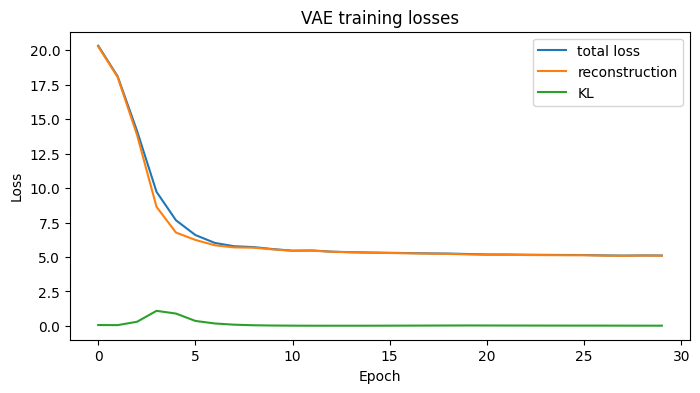

In [13]:

history_df = pd.DataFrame(vae_history.history)

plt.figure(figsize=(8, 4))
plt.plot(history_df["loss"], label="total loss")
plt.plot(history_df["reconstruction_loss"], label="reconstruction")
plt.plot(history_df["kl_loss"], label="KL")
plt.title("VAE training losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


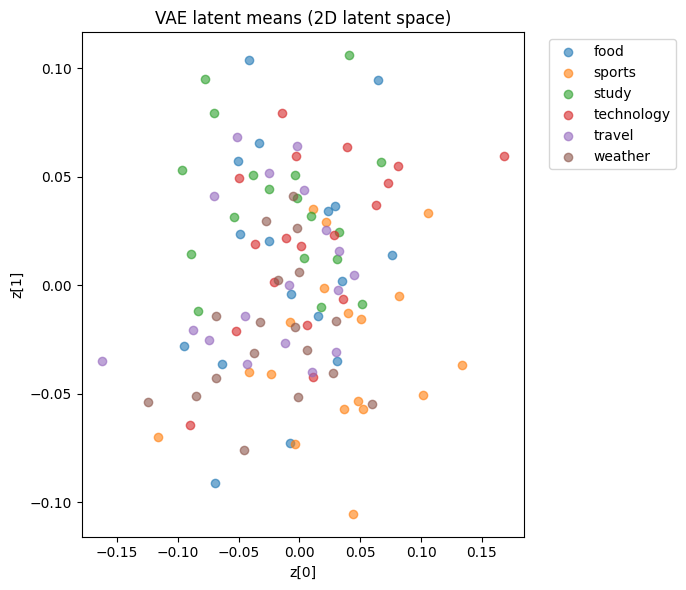

In [14]:

z_mean_val, z_log_var_val, z_val = vae_encoder.predict(X_val, verbose=0)

plt.figure(figsize=(7, 6))
for topic in sorted(set(topic_val)):
    mask = np.array(topic_val) == topic
    plt.scatter(z_mean_val[mask, 0], z_mean_val[mask, 1], alpha=0.6, label=topic)

plt.title("VAE latent means (2D latent space)")
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [15]:

def decode_from_vae_point(point, top_k=8):
    point = np.array(point, dtype="float32").reshape(1, -1)
    decoded = vae_decoder.predict(point, verbose=0)[0]
    return top_words_from_probs(decoded, vocab, top_k=top_k)

sample_points = [
    (-2.0, -2.0),
    (-2.0,  0.0),
    (-2.0,  2.0),
    ( 0.0, -2.0),
    ( 0.0,  0.0),
    ( 0.0,  2.0),
    ( 2.0, -2.0),
    ( 2.0,  0.0),
    ( 2.0,  2.0),
]

rows = []
for px, py in sample_points:
    words = [w for w, _ in decode_from_vae_point((px, py), top_k=6)]
    rows.append({"latent_point": (px, py), "decoded_top_words": ", ".join(words)})

pd.DataFrame(rows)


,latent_point,decoded_top_words
0,"(-2.0, -2.0)","a, our, the, during, with, this"
1,"(-2.0, 0.0)","a, our, the, during, with, after"
2,"(-2.0, 2.0)","a, our, the, with, during, this"
3,"(0.0, -2.0)","a, the, our, with, this, during"
4,"(0.0, 0.0)","a, our, the, this, during, with"
5,"(0.0, 2.0)","a, our, the, this, during, with"
6,"(2.0, -2.0)","a, the, our, with, this, during"
7,"(2.0, 0.0)","a, our, the, during, this, with"
8,"(2.0, 2.0)","a, our, the, during, with, this"


In [16]:

def inspect_user_text_with_vae(text):
    _, bow = inspect_text_representation(text)
    z_mean, z_log_var, z = vae_encoder.predict(bow[None, :], verbose=0)
    decoded = vae_decoder.predict(z, verbose=0)[0]

    print("\nz_mean:", np.round(z_mean[0], 3))
    print("z_log_var:", np.round(z_log_var[0], 3))
    print("\nDecoded top words:")
    for word, prob in top_words_from_probs(decoded, vocab, top_k=8):
        print(f"{word:15s} {prob:.3f}")

inspect_user_text_with_vae(user_text)


Normalized text: the student writes the report carefully
Token IDs: [2, 21, 94, 2, 10, 37]
Ordered tokens: [np.str_('the'), np.str_('student'), np.str_('writes'), np.str_('the'), np.str_('report'), np.str_('carefully')]
Bag-of-words active words: [np.str_('before'), np.str_('trail'), np.str_('drill'), np.str_('dessert')]

z_mean: [0.05  0.041]
z_log_var: [-0.097 -0.027]

Decoded top words:
a               0.324
our             0.296
the             0.252
this            0.134
during          0.130
with            0.126
after           0.109
before          0.108



### Why VAEs mattered historically

VAEs made an important conceptual leap:

- an autoencoder can reconstruct,
- but a VAE can **sample** from a structured latent space.

This idea influenced later generative modeling because it taught us to care not only about compression, but also about whether the latent space is **smooth, navigable, and sampleable**.



## 9. GANs: adversarial generation

GANs are very different from autoencoders and VAEs.

There is no explicit reconstruction target.  
Instead, there is a game between two networks:

- **Generator**: tries to create fake samples that look real.
- **Discriminator**: tries to tell real samples from fake samples.

### Better analogy: the fake student essay game

Imagine:

- one student secretly writes fake essays,
- the teacher tries to guess whether an essay came from the real class archive or from the student.

The student gets better at imitating the archive.  
The teacher gets better at spotting subtle flaws.  
Over time, the fake essays become harder to detect.

### Important note for text

GANs became famous mainly for images.  
For raw text, they are much trickier because **words are discrete**.  
Sampling a word is not as smooth as sampling pixel values, which makes gradient-based training harder.

So in this notebook we will use a **toy GAN on bag-of-words text features**.
That makes the adversarial idea visible, even though it is not how most modern text generation systems are built.


In [17]:

gan_latent_dim = 16

generator = keras.Sequential(
    [
        layers.Input(shape=(gan_latent_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(input_dim, activation="sigmoid"),
    ],
    name="text_feature_generator",
)

discriminator = keras.Sequential(
    [
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ],
    name="text_feature_discriminator",
)

bce = keras.losses.BinaryCrossentropy()
gen_optimizer = keras.optimizers.Adam(1e-3)
disc_optimizer = keras.optimizers.Adam(1e-3)

batch_size = 32
dataset = tf.data.Dataset.from_tensor_slices(X_train).shuffle(len(X_train)).batch(batch_size)

gan_history = {"d_loss": [], "g_loss": []}

num_steps = 250
dataset_iter = iter(dataset.repeat())

for step in range(num_steps):
    real_batch = next(dataset_iter)
    current_batch_size = tf.shape(real_batch)[0]
    noise = tf.random.normal((current_batch_size, gan_latent_dim))

    with tf.GradientTape() as disc_tape:
        fake_batch = generator(noise, training=True)
        real_pred = discriminator(real_batch, training=True)
        fake_pred = discriminator(fake_batch, training=True)

        real_labels = tf.ones_like(real_pred) * 0.9
        fake_labels = tf.zeros_like(fake_pred)

        d_loss = bce(real_labels, real_pred) + bce(fake_labels, fake_pred)

    disc_grads = disc_tape.gradient(d_loss, discriminator.trainable_weights)
    disc_optimizer.apply_gradients(zip(disc_grads, discriminator.trainable_weights))

    noise = tf.random.normal((current_batch_size, gan_latent_dim))
    with tf.GradientTape() as gen_tape:
        fake_batch = generator(noise, training=True)
        fake_pred = discriminator(fake_batch, training=True)
        g_loss = bce(tf.ones_like(fake_pred), fake_pred)

    gen_grads = gen_tape.gradient(g_loss, generator.trainable_weights)
    gen_optimizer.apply_gradients(zip(gen_grads, generator.trainable_weights))

    gan_history["d_loss"].append(float(d_loss))
    gan_history["g_loss"].append(float(g_loss))


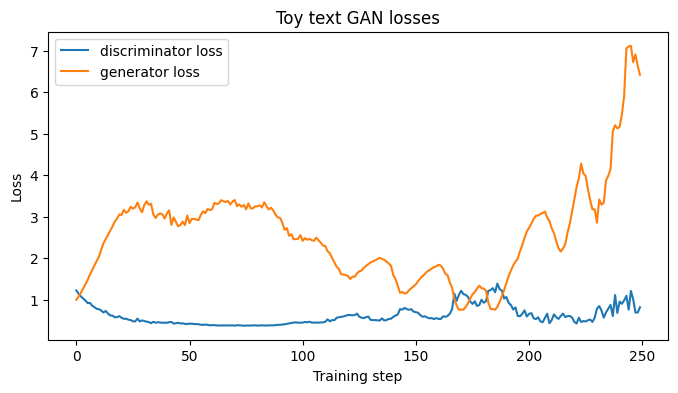

In [18]:

plt.figure(figsize=(8, 4))
plt.plot(gan_history["d_loss"], label="discriminator loss")
plt.plot(gan_history["g_loss"], label="generator loss")
plt.title("Toy text GAN losses")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [19]:

noise = tf.random.normal((5, gan_latent_dim))
generated_vectors = generator.predict(noise, verbose=0)

rows = []
for i, vec in enumerate(generated_vectors):
    top_words = [w for w, _ in top_words_from_probs(vec, vocab, top_k=8)]
    nearest_idx = int(np.argmax(cosine_similarity(vec[None, :], X_bow)[0]))
    rows.append({
        "sample_id": i,
        "generated_top_words": ", ".join(top_words),
        "nearest_real_sentence": sentences[nearest_idx],
    })

pd.DataFrame(rows)


,sample_id,generated_top_words,nearest_real_sentence
0,0,"this, guests, slowly, the, match, packs, prepa...",our family visits the village early
1,1,"guests, this, after, slowly, the, visits, pack...",our family visits the village early
2,2,"guests, this, slowly, the, after, match, prepa...",our family visits the village early
3,3,"this, guests, slowly, the, with, after, packs,...",our cook serves the dinner after work
4,4,"this, guests, slowly, the, match, after, with,...",our family visits the village early



### What should you notice about GANs here?

This toy GAN can generate **plausible word mixtures**, but not clean, fluent sentences.

That is actually a useful lesson.

For text, GANs ran into a major challenge:

- the generator wants to output discrete tokens,
- but the training signal flows more naturally through continuous values.

That is one reason the field gradually shifted toward **autoregressive sequence models** and then **transformers** for text generation.

So GANs remain historically important, but for text they are more of a stepping stone than the dominant modern approach.



## 10. The missing bridge: transformers and attention

If GANs are awkward for text, what replaced them?

The key answer is:

> **models that generate text one token at a time while using attention to look at context**

This leads us to **transformers**.

### Better analogy: a group discussion

Suppose each word in a sentence is a student in a discussion circle.

When it is a word's turn to speak, it asks:

- Which other words in the sentence matter most for understanding me?
- Which earlier words should I focus on?

Attention is a learned way to answer that question.

### Why this matters

Attention lets the model directly connect:

- subjects with verbs,
- adjectives with nouns,
- earlier context with later tokens,

without having to squeeze everything through one fixed bottleneck.



## 11. A tiny attention demo by hand

Before using library transformer layers, let us visualize the basic idea:

1. turn tokens into embeddings,
2. project them into **queries**, **keys**, and **values**,
3. compute attention scores,
4. mix information from different tokens.

This is not a trained model yet.  
It is just a small numerical demonstration so the mechanics feel concrete.


In [20]:

attention_demo_text = "the student reads the report carefully"
demo_ids = [i for i in int_vectorizer([attention_demo_text]).numpy()[0] if i != 0]
demo_tokens = [vocab[i] for i in demo_ids]

rng = np.random.default_rng(42)
embed_dim = 8

embedding_table = rng.normal(size=(vocab_size, embed_dim)).astype("float32")
token_embeddings = embedding_table[demo_ids]

Wq = rng.normal(size=(embed_dim, embed_dim)).astype("float32")
Wk = rng.normal(size=(embed_dim, embed_dim)).astype("float32")
Wv = rng.normal(size=(embed_dim, embed_dim)).astype("float32")

Q = token_embeddings @ Wq
K = token_embeddings @ Wk
V = token_embeddings @ Wv

scores = Q @ K.T / np.sqrt(embed_dim)
scores = scores - scores.max(axis=1, keepdims=True)
weights = np.exp(scores) / np.exp(scores).sum(axis=1, keepdims=True)
context = weights @ V

print("Tokens:", demo_tokens)
print("Attention matrix shape:", weights.shape)


Tokens: [np.str_('the'), np.str_('student'), np.str_('reads'), np.str_('the'), np.str_('report'), np.str_('carefully')]
Attention matrix shape: (6, 6)


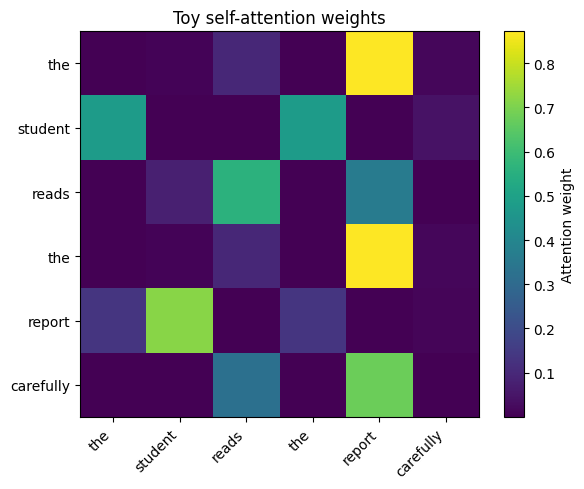

In [21]:

plt.figure(figsize=(6, 5))
plt.imshow(weights, aspect="auto")
plt.xticks(range(len(demo_tokens)), demo_tokens, rotation=45, ha="right")
plt.yticks(range(len(demo_tokens)), demo_tokens)
plt.title("Toy self-attention weights")
plt.colorbar(label="Attention weight")
plt.tight_layout()
plt.show()



The heatmap above shows a simple version of the question:

> **When processing token i, how much attention does it give to token j?**

Real transformers learn these projections during training and usually use **multiple attention heads** so different heads can focus on different patterns.



## 12. A tiny transformer language model

Now we build a small **next-token model** using standard library components:

- token embeddings,
- positional embeddings,
- multi-head attention,
- feed-forward layers,
- a vocabulary output layer.

This is still tiny, but it shows the same basic recipe used in larger language models:

> given earlier tokens, predict the next token.


In [22]:

token_sequences = int_vectorizer(tf.constant(sentences)).numpy().astype("int32")
lm_inputs = token_sequences[:, :-1]
lm_targets = token_sequences[:, 1:]
lm_sample_weights = (lm_targets != 0).astype("float32")

lm_input_train, lm_input_val, lm_target_train, lm_target_val, sw_train, sw_val = train_test_split(
    lm_inputs, lm_targets, lm_sample_weights, test_size=0.2, random_state=42
)

context_length = lm_inputs.shape[1]
transformer_embed_dim = 32
num_heads = 2
ff_dim = 64

class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(vocab_size, embed_dim, mask_zero=False)
        self.pos_emb = layers.Embedding(maxlen, embed_dim)

    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[-1], delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim, dropout=rate)
        self.ffn = keras.Sequential(
            [
                layers.Dense(ff_dim, activation="relu"),
                layers.Dense(embed_dim),
            ]
        )
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(rate)
        self.drop2 = layers.Dropout(rate)

    def call(self, x, training=None, return_attention=False):
        attn_output, attn_scores = self.att(
            x,
            x,
            use_causal_mask=True,
            return_attention_scores=True,
            training=training,
        )
        attn_output = self.drop1(attn_output, training=training)
        out1 = self.norm1(x + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.drop2(ffn_output, training=training)
        out2 = self.norm2(out1 + ffn_output)

        if return_attention:
            return out2, attn_scores
        return out2

class TinyTransformerLM(keras.Model):
    def __init__(self, vocab_size, maxlen, embed_dim, num_heads, ff_dim):
        super().__init__()
        self.embedding = TokenAndPositionEmbedding(maxlen, vocab_size, embed_dim)
        self.block = TransformerBlock(embed_dim, num_heads, ff_dim)
        self.dropout = layers.Dropout(0.1)
        self.classifier = layers.Dense(vocab_size)

    def call(self, x, training=None, return_attention=False):
        x = self.embedding(x)
        if return_attention:
            x, scores = self.block(x, training=training, return_attention=True)
            x = self.dropout(x, training=training)
            logits = self.classifier(x)
            return logits, scores
        x = self.block(x, training=training)
        x = self.dropout(x, training=training)
        return self.classifier(x)

transformer_lm = TinyTransformerLM(
    vocab_size=vocab_size,
    maxlen=context_length,
    embed_dim=transformer_embed_dim,
    num_heads=num_heads,
    ff_dim=ff_dim,
)

loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

transformer_lm.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=loss_fn,
)

start_time = time.time()
transformer_history = transformer_lm.fit(
    lm_input_train,
    lm_target_train,
    sample_weight=sw_train,
    validation_data=(lm_input_val, lm_target_val, sw_val),
    epochs=20,
    batch_size=32,
    verbose=0,
)
transformer_training_time = time.time() - start_time

print(f"Training time: {transformer_training_time:.2f} seconds")


Training time: 4.43 seconds


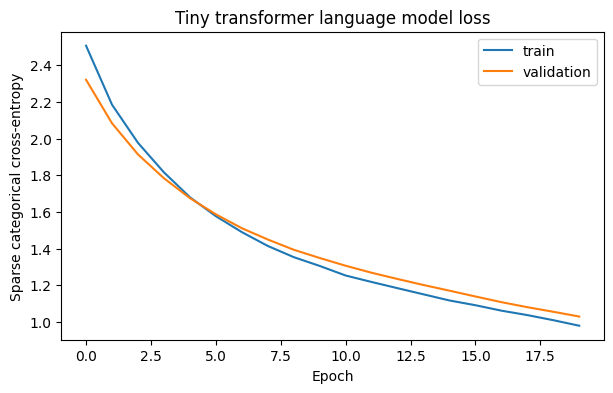

In [23]:

plt.figure(figsize=(7, 4))
plt.plot(transformer_history.history["loss"], label="train")
plt.plot(transformer_history.history["val_loss"], label="validation")
plt.title("Tiny transformer language model loss")
plt.xlabel("Epoch")
plt.ylabel("Sparse categorical cross-entropy")
plt.legend()
plt.show()


In [32]:

def text_to_ids(text):
    ids = int_vectorizer(tf.constant([normalize_text(text)])).numpy()[0].tolist()
    ids = [i for i in ids if i != 0]
    return ids

def ids_to_text(ids):
    tokens = [vocab[i] for i in ids if i != 0 and i < len(vocab) and vocab[i] not in ("", "[UNK]")]
    return " ".join(tokens)

def generate_with_transformer(prompt, max_new_tokens=8, temperature=1.0):
    generated = text_to_ids(prompt)

    if len(generated) == 0:
        raise ValueError("Please enter at least one known token from the notebook vocabulary.")

    for _ in range(max_new_tokens):
        context = generated[-context_length:]
        padded = context + [0] * (context_length - len(context))
        logits = transformer_lm(tf.constant([padded]), training=False).numpy()[0]

        next_position = max(len(context) - 1, 0)
        next_token_logits = logits[next_position] / temperature

        probs = tf.nn.softmax(next_token_logits).numpy()
        next_id = int(np.random.choice(len(probs), p=probs))

        if next_id == 0:
            break

        generated.append(next_id)

    return generated

prompt_text = "the student"
generated_ids = generate_with_transformer(prompt_text, max_new_tokens=8, temperature=0.9)

print("Prompt:", prompt_text)
print("Generated token IDs:", generated_ids)
print("Generated text:", ids_to_text(generated_ids))


Prompt: the student
Generated token IDs: [2, 21, 47, 2, 131, 45, 44, 121, 115, 117]
Generated text: the student discusses the soup for guests at sunrise quickly


In [25]:

def show_transformer_representation(text):
    ids = text_to_ids(text)
    if len(ids) == 0:
        print("No known tokens were found.")
        return

    context = ids[-context_length:]
    padded = context + [0] * (context_length - len(context))

    embeddings = transformer_lm.embedding(tf.constant([padded])).numpy()[0][:len(context)]
    print("Tokens:", [vocab[i] for i in context])
    print("Token IDs:", context)
    print("Embedding matrix shape:", embeddings.shape)
    print("First 3 embedding rows (rounded):")
    print(np.round(embeddings[:3], 3))

show_transformer_representation(prompt_text)


Tokens: [np.str_('the'), np.str_('student')]
Token IDs: [2, 21]
Embedding matrix shape: (2, 32)
First 3 embedding rows (rounded):
[[-0.062 -0.008 -0.013 -0.042 -0.069  0.045  0.076  0.061  0.008 -0.063
   0.011  0.045  0.019 -0.009 -0.059 -0.034  0.049 -0.052  0.058  0.053
  -0.024 -0.06  -0.012  0.061  0.085 -0.02   0.056  0.058  0.03  -0.009
  -0.065 -0.063]
 [-0.05  -0.011  0.036  0.049  0.026 -0.075  0.031 -0.103 -0.012 -0.022
  -0.09  -0.041 -0.068 -0.007  0.058  0.068  0.039  0.014  0.055 -0.01
  -0.018 -0.028 -0.007 -0.029 -0.104  0.02  -0.056  0.005  0.019 -0.008
  -0.106 -0.014]]


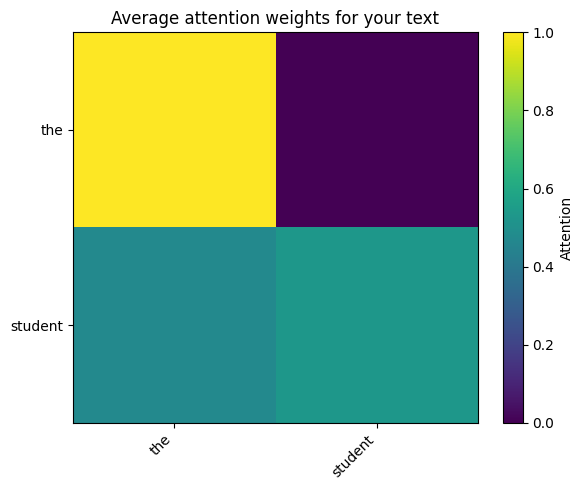

In [26]:

def plot_attention_for_text(text):
    ids = text_to_ids(text)
    if len(ids) == 0:
        print("No known tokens were found.")
        return

    context = ids[-context_length:]
    padded = context + [0] * (context_length - len(context))

    _, attention_scores = transformer_lm(
        tf.constant([padded]),
        training=False,
        return_attention=True,
    )

    # attention_scores shape: (batch, heads, query_len, key_len)
    scores = attention_scores.numpy()[0].mean(axis=0)
    scores = scores[:len(context), :len(context)]
    tokens = [vocab[i] for i in context]

    plt.figure(figsize=(6, 5))
    plt.imshow(scores, aspect="auto")
    plt.xticks(range(len(tokens)), tokens, rotation=45, ha="right")
    plt.yticks(range(len(tokens)), tokens)
    plt.title("Average attention weights for your text")
    plt.colorbar(label="Attention")
    plt.tight_layout()
    plt.show()

plot_attention_for_text(prompt_text)



## 13. Let the you type your own text

Edit the next cell and try your own examples.

Suggestions:

- `"the robot predicts the signal"`
- `"the chef serves dinner"`
- `"the student reviews the project"`

Then rerun the cells below to inspect:

- token IDs,
- active bag-of-words features,
- autoencoder reconstruction,
- VAE latent location,
- transformer embeddings,
- transformer attention,
- generated continuation.


=== Basic representation ===
Normalized text: the chef serves dinner
Token IDs: [2, 109, 85, 48]
Ordered tokens: [np.str_('the'), np.str_('chef'), np.str_('serves'), np.str_('dinner')]
Bag-of-words active words: [np.str_('discusses'), np.str_('slowly'), np.str_('class')]

=== Autoencoder view ===
Normalized text: the chef serves dinner
Token IDs: [2, 109, 85, 48]
Ordered tokens: [np.str_('the'), np.str_('chef'), np.str_('serves'), np.str_('dinner')]
Bag-of-words active words: [np.str_('discusses'), np.str_('slowly'), np.str_('class')]

Latent vector:
[ 0.714 -1.977 -1.052  1.771 -1.351 -2.53   1.243 -1.749]

Top reconstructed words:
a               0.299
the             0.263
our             0.214
with            0.210
report          0.138
after           0.130
suddenly        0.119
rain            0.113

Nearest training sentences after reconstruction:
- our family packs the dessert after work
- our chef shares the salad after work
- the family shares this bread after work

=== VAE v

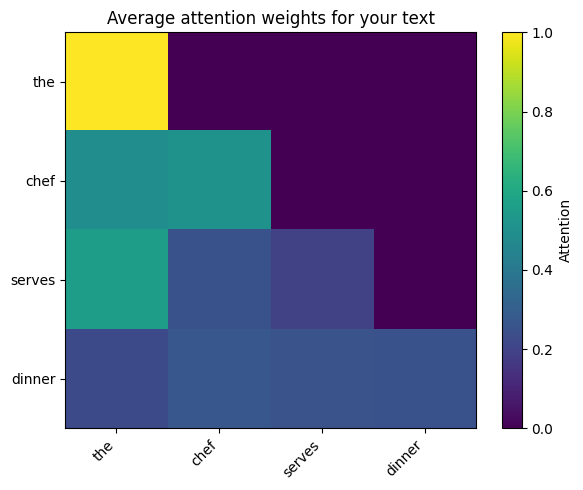

In [42]:

my_text = "the chef serves dinner"

print("=== Basic representation ===")
inspect_text_representation(my_text)

print("\n=== Autoencoder view ===")
reconstruct_with_autoencoder(my_text)

print("\n=== VAE view ===")
inspect_user_text_with_vae(my_text)

print("\n=== Transformer embeddings ===")
show_transformer_representation(my_text)

print("\n=== Transformer generation ===")
generated_ids = generate_with_transformer(my_text, max_new_tokens=8, temperature=0.9)
print(ids_to_text(generated_ids))

plot_attention_for_text(my_text)



## 14. So how did the field move toward LLMs?

This notebook showed a progression of ideas.

### Autoencoders
Taught us that neural networks can learn useful compressed internal representations.

### VAEs
Added smooth latent spaces and probabilistic sampling.

### GANs
Showed how adversarial training can create sharp, realistic outputs, especially for continuous data like images.

### Transformers
Solved a major language problem more naturally:

- keep token order,
- let each token attend to others,
- generate text token by token,
- scale to huge corpora.

That is why modern LLMs are much more closely related to the **transformer section** of this notebook than to the GAN section.

### A compact mental model

- **Autoencoder** = compress and reconstruct
- **VAE** = compress, regularize, and sample
- **GAN** = generate by competition
- **Transformer** = generate by attention and next-token prediction
- **LLM** = a very large transformer trained on enormous text corpora



## 15. Stronger library tools you should know

After understanding small examples, it is good to know which **real libraries and tools** are commonly used.

### For text preprocessing and transformer-based NLP
- **TensorFlow Text / KerasNLP**
- **Hugging Face Transformers**
- **PyTorch transformer modules**

### For studying more
- TensorFlow text tutorials: https://www.tensorflow.org/text/tutorials
- TensorFlow text overview: https://www.tensorflow.org/text
- Keras transformer text example: https://keras.io/examples/nlp/text_classification_with_transformer/
- Keras NLP examples: https://keras.io/examples/nlp/
- PyTorch Transformer docs: https://docs.pytorch.org/docs/stable/generated/torch.nn.Transformer.html
- Original VAE paper: https://arxiv.org/abs/1312.6114
- Original GAN paper: https://arxiv.org/abs/1406.2661
- Attention Is All You Need: https://arxiv.org/abs/1706.03762

### Practical note

When people build real modern text systems, they usually do **not** hand-code a large model from scratch.  
They rely on well-tested library implementations and prebuilt components, then fine-tune or adapt them to their task.



## 16. Ethical considerations for text generation

Text generation can be impressive, but it also creates risks.

Examples:

- convincing misinformation,
- plagiarism or unattributed imitation,
- biased or harmful generations,
- overconfidence in fabricated content.

### Good habits
- verify factual outputs,
- label generated text when appropriate,
- document model limits,
- and keep human judgment in the loop.

This matters even in classroom experiments, because understanding responsible use is part of understanding the technology itself.



## 17. Summary

In this notebook, you saw a progression from earlier generative ideas to transformer-based text generation:

- **Autoencoders** compress and reconstruct.
- **VAEs** learn distributions in latent space and allow sampling.
- **GANs** generate through an adversarial game, but are awkward for raw text.
- **Transformers** use attention and next-token prediction, which leads directly toward modern LLMs.

You also saw how to:

- tokenize text,
- inspect numeric representations,
- encode your own sentence,
- visualize latent spaces,
- inspect attention,
- and generate text continuations from your own prompt.

This prepares you well for a later notebook focused specifically on **LLMs, transformers at larger scale, and modern language-model tooling**.



## 18. Suggested exercises

1. Change the corpus templates and add a new topic.  
   Does the latent space become more separated?

2. Change the bottleneck size of the autoencoder.  
   What happens when it is too small or much larger?

3. Change the VAE latent dimension from 2 to 4 or 8.  
   What do you gain, and what do you lose in interpretability?

4. Try different prompt texts in the transformer section.  
   Which prompts generate more coherent continuations?

5. Increase the transformer depth or number of heads.  
   Does the loss improve enough to justify the extra computation?

6. Compare the generated outputs of:
   - autoencoder reconstruction,
   - VAE decoding,
   - GAN word mixtures,
   - transformer next-token generation.

Which one feels most natural for text, and why?
